# Presentation Charts
## Optimizing Board Game Discovery Through Text Vectorization and Representative Clustering

**By:** Santiago, Uy, Angos, Araña, Ramirez  
**Program:** BS Data Science — Asian Institute of Management

---

### Purpose of This Notebook

This notebook generates charts that are **not EDA** but are needed for the presentation slides:

1. **Model Performance Comparison** (Slide 8) — bar chart of model RMSE results vs baseline
2. **User vs Item Features Diagram** (Slide 6) — visual addressing Prof. Leo's comment about explicit user-features

These are separated from the EDA notebook because they visualize modeling outcomes and system architecture, not data exploration.

**Charts are exported at 300 DPI** to the `eda_charts/` folder for direct use in the Canva presentation.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

os.makedirs('eda_charts', exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'

print('Libraries loaded!')

Libraries loaded!


---
## 1. Model Performance Comparison Chart (Slide 8)

### Context

Slide 8 in the current Canva presentation still has the template placeholder (game grid with "weather", "name", "food"). This chart replaces it with an actual comparison of model results from the modeling phase.

### Results (from modeling notebook)

| Model | Hyperparameter | RMSE | % Improvement over Baseline |
|-------|---------------|------|----------------------------|
| Baseline (random) | — | 0.686 | — |
| kNN | n = 11 | 0.59 | 14.45% |
| Lasso Regression | α = 0.001 | 0.58 | 15.61% |
| Ridge Regression | α = 1 | 0.58 | **15.67%** |

**Key insight for speaker notes:** Ridge Regression achieves the best RMSE of 0.58 — a 15.67% improvement over the random baseline. All three models perform similarly, suggesting that the TF-IDF + SVD feature pipeline captures most of the available predictive signal, and the choice of model matters less than the feature representation.

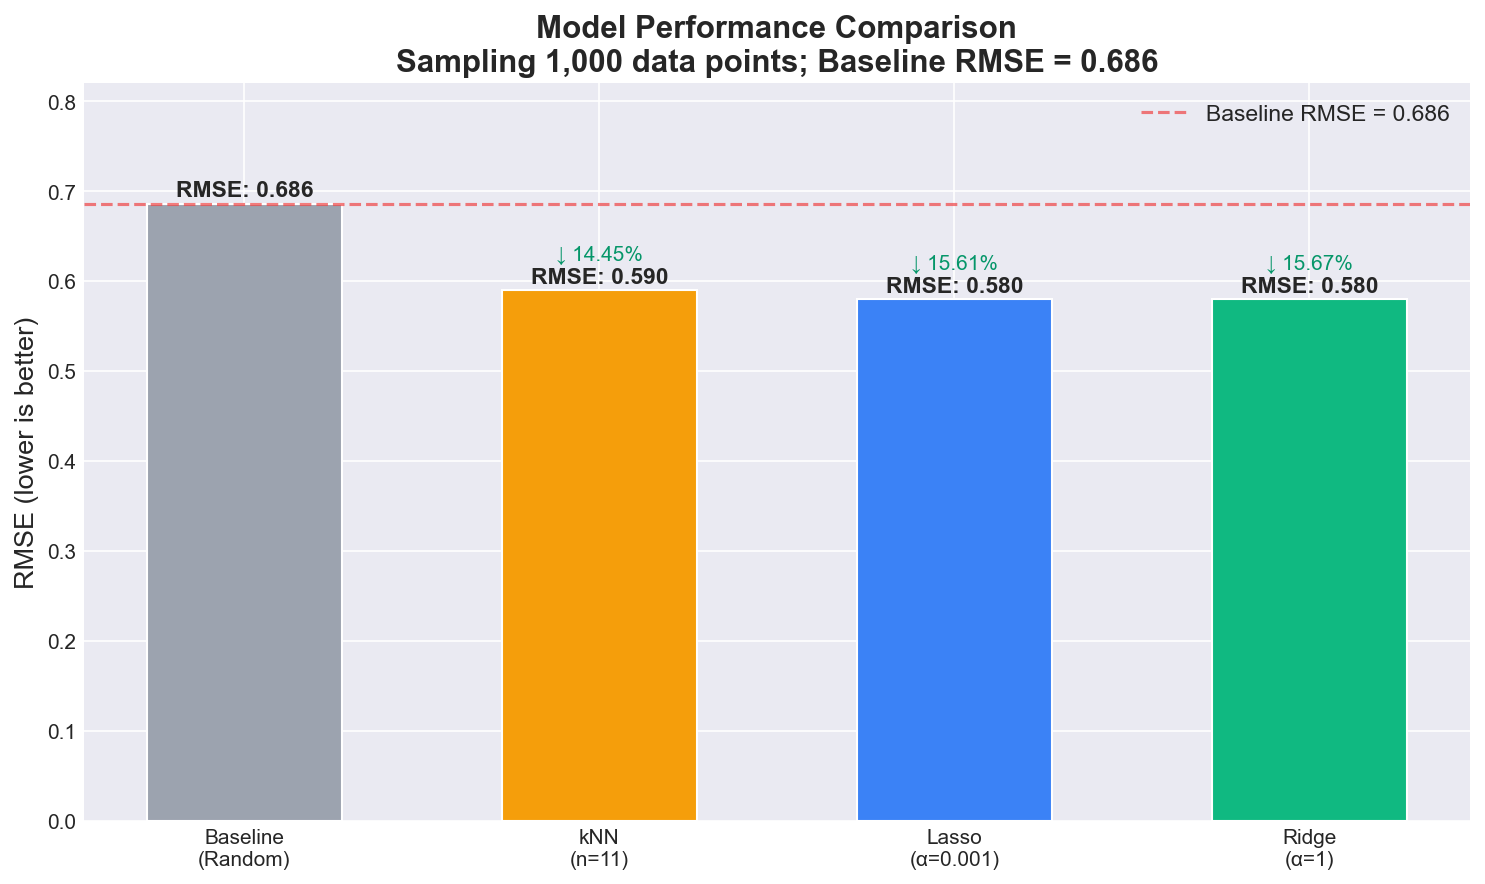


Model Results Summary:
  Baseline (Random)    RMSE=0.686  improvement=—
  kNN (n=11)           RMSE=0.590  improvement=14.45%
  Lasso (α=0.001)      RMSE=0.580  improvement=15.61%
  Ridge (α=1)          RMSE=0.580  improvement=15.67%


In [2]:
# CHART: Model Performance Comparison — for Slide 8
fig, ax = plt.subplots(figsize=(10, 6))

models = ['Baseline\n(Random)', 'kNN\n(n=11)', 'Lasso\n(\u03b1=0.001)', 'Ridge\n(\u03b1=1)']
rmses = [0.686, 0.59, 0.58, 0.58]
improvements = ['\u2014', '14.45%', '15.61%', '15.67%']
bar_colors = ['#9CA3AF', '#F59E0B', '#3B82F6', '#10B981']

bars = ax.bar(models, rmses, color=bar_colors, edgecolor='white', width=0.55)
ax.axhline(y=0.686, color='#EF4444', linestyle='--', linewidth=1.5, alpha=0.7, 
           label='Baseline RMSE = 0.686')

for bar, rmse, imp in zip(bars, rmses, improvements):
    y_pos = bar.get_height() + 0.008
    ax.text(bar.get_x() + bar.get_width()/2, y_pos, 
            f'RMSE: {rmse:.3f}', ha='center', fontsize=11, fontweight='bold')
    if imp != '\u2014':
        ax.text(bar.get_x() + bar.get_width()/2, y_pos + 0.025, 
                f'\u2193 {imp}', ha='center', fontsize=10, color='#059669')

ax.set_ylabel('RMSE (lower is better)', fontsize=13)
ax.set_title('Model Performance Comparison\n'
             'Sampling 1,000 data points; Baseline RMSE = 0.686', 
             fontsize=15, fontweight='bold')
ax.set_ylim(0, 0.82)
ax.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.savefig('eda_charts/10_model_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nModel Results Summary:')
for m, r, i in zip(models, rmses, improvements):
    print(f'  {m.replace(chr(10), " "):20s} RMSE={r:.3f}  improvement={i}')

---
## 2. User-Features vs Item-Features Diagram (Slide 6)

### Addressing Prof. Leo's Comment

> *"Project is a model-based recommender system, thus variables to be used as 'user-features' should be explicit."*

This diagram explicitly defines:

- **User-Feature:** The retailer's query (game title or description), vectorized by the trained TF-IDF model into a 500-dimensional vector at query time.
- **Item-Features:** The pre-computed TF-IDF vectors for all 10,000 games in the database, reduced via SVD to 500 components.
- **Where they meet:** Cosine similarity between the user-feature vector and item-feature vectors drives retrieval, while the ML model predicts Hit/Average/Flop.

This is a **content-based recommender system** — the user profile is derived entirely from the item they express interest in, not from collaborative purchase/rating history.

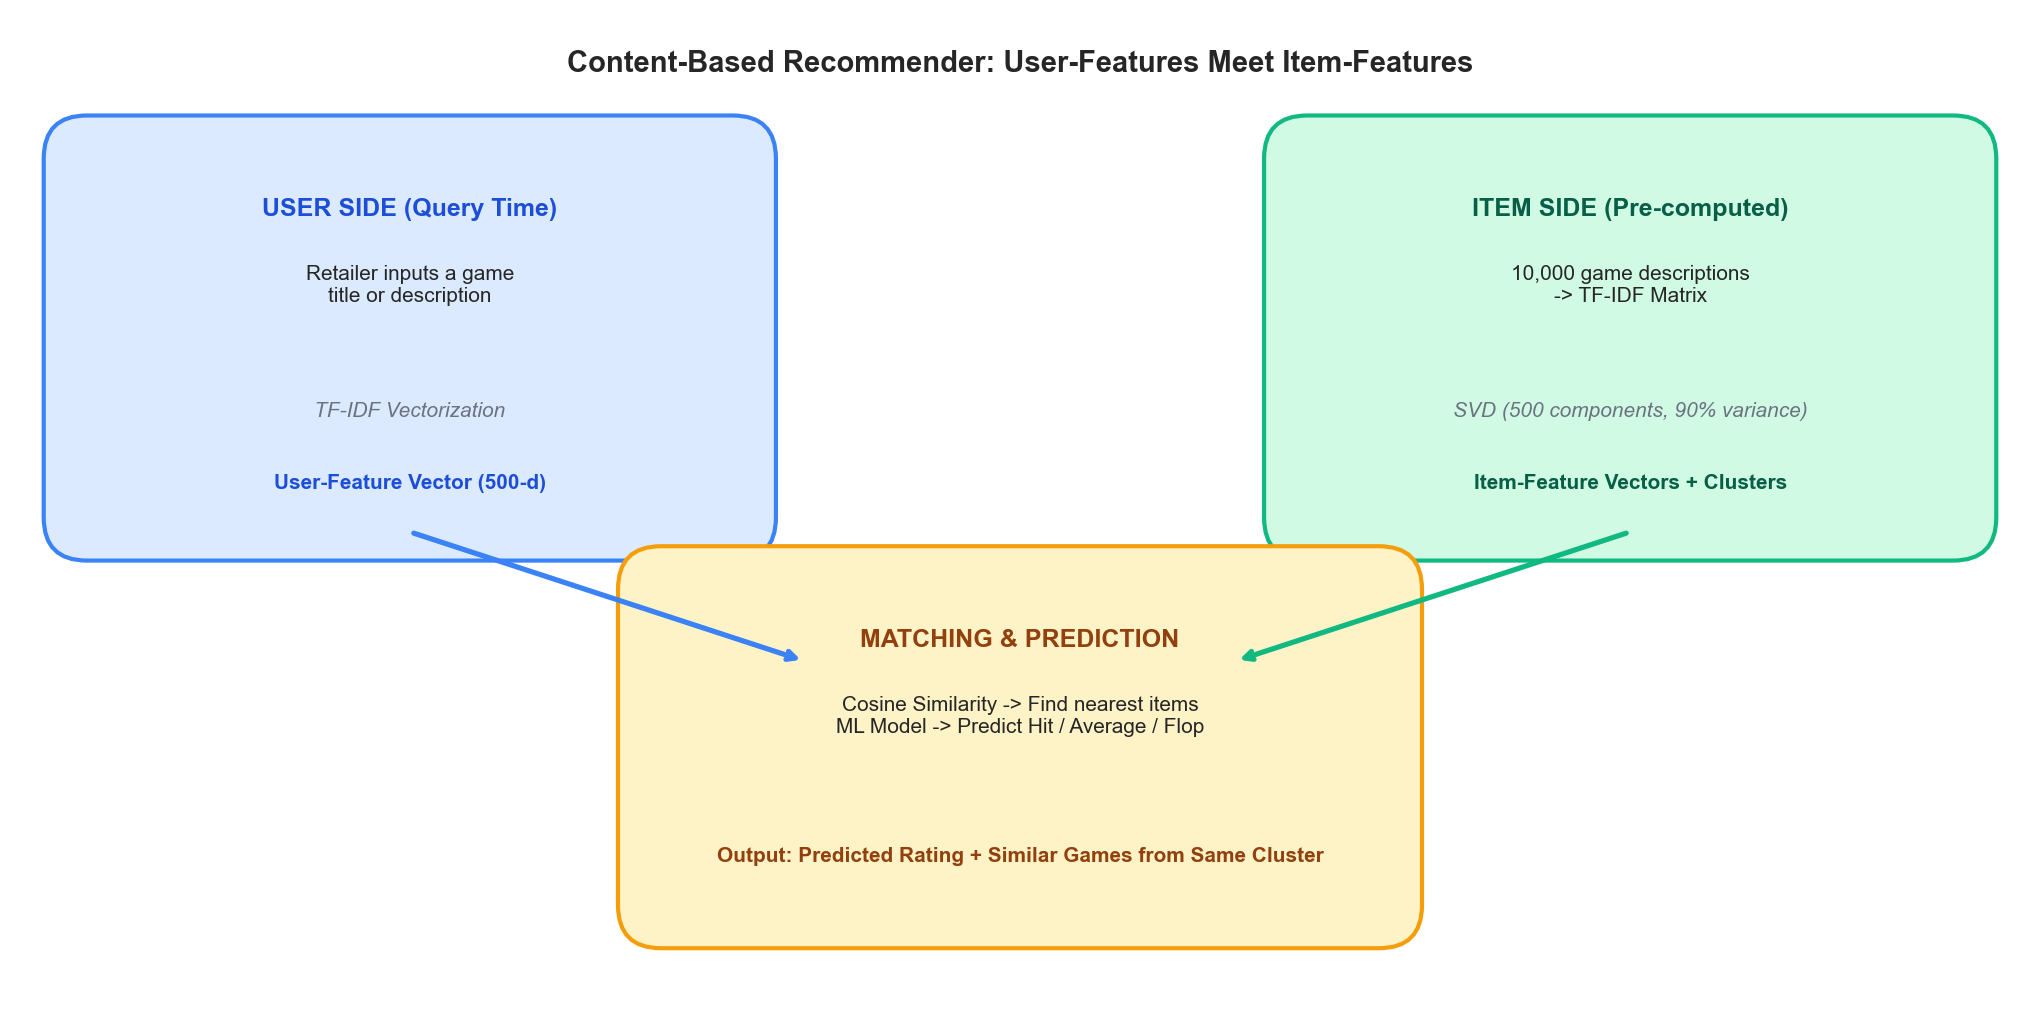

Upload 12_user_item_features.png to Canva for Slide 6.


In [3]:
# CHART: User vs Item Feature Flow Diagram — for Slide 6
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14)
ax.set_ylim(0, 7)
ax.set_aspect('equal')
ax.axis('off')

# Title
ax.text(7, 6.6, 'Content-Based Recommender: User-Features Meet Item-Features', 
        ha='center', fontsize=14, fontweight='bold')

# USER SIDE (left)
user_box = mpatches.FancyBboxPatch((0.5, 3.5), 4.5, 2.5, boxstyle='round,pad=0.3', 
                                     facecolor='#DBEAFE', edgecolor='#3B82F6', linewidth=2)
ax.add_patch(user_box)
ax.text(2.75, 5.6, 'USER SIDE (Query Time)', 
        ha='center', fontsize=12, fontweight='bold', color='#1D4ED8')
ax.text(2.75, 5.0, 'Retailer inputs a game\ntitle or description', 
        ha='center', fontsize=10)
ax.text(2.75, 4.2, 'TF-IDF Vectorization', 
        ha='center', fontsize=10, style='italic', color='#6B7280')
ax.text(2.75, 3.7, 'User-Feature Vector (500-d)', 
        ha='center', fontsize=10, fontweight='bold', color='#1D4ED8')

# ITEM SIDE (right)
item_box = mpatches.FancyBboxPatch((9, 3.5), 4.5, 2.5, boxstyle='round,pad=0.3',
                                     facecolor='#D1FAE5', edgecolor='#10B981', linewidth=2)
ax.add_patch(item_box)
ax.text(11.25, 5.6, 'ITEM SIDE (Pre-computed)', 
        ha='center', fontsize=12, fontweight='bold', color='#065F46')
ax.text(11.25, 5.0, '10,000 game descriptions\n-> TF-IDF Matrix', 
        ha='center', fontsize=10)
ax.text(11.25, 4.2, 'SVD (500 components, 90% variance)', 
        ha='center', fontsize=10, style='italic', color='#6B7280')
ax.text(11.25, 3.7, 'Item-Feature Vectors + Clusters', 
        ha='center', fontsize=10, fontweight='bold', color='#065F46')

# CENTER — where they meet
center_box = mpatches.FancyBboxPatch((4.5, 0.8), 5, 2.2, boxstyle='round,pad=0.3',
                                       facecolor='#FEF3C7', edgecolor='#F59E0B', linewidth=2)
ax.add_patch(center_box)
ax.text(7, 2.6, 'MATCHING & PREDICTION', 
        ha='center', fontsize=12, fontweight='bold', color='#92400E')
ax.text(7, 2.0, 'Cosine Similarity -> Find nearest items\n'
        'ML Model -> Predict Hit / Average / Flop', ha='center', fontsize=10)
ax.text(7, 1.1, 'Output: Predicted Rating + Similar Games from Same Cluster', 
        ha='center', fontsize=10, fontweight='bold', color='#92400E')

# Arrows
ax.annotate('', xy=(5.5, 2.5), xytext=(2.75, 3.4), 
            arrowprops=dict(arrowstyle='->', color='#3B82F6', lw=2.5))
ax.annotate('', xy=(8.5, 2.5), xytext=(11.25, 3.4), 
            arrowprops=dict(arrowstyle='->', color='#10B981', lw=2.5))

plt.tight_layout()
plt.savefig('eda_charts/12_user_item_features.png', dpi=300, bbox_inches='tight')
plt.show()

print('Upload 12_user_item_features.png to Canva for Slide 6.')

---
## Chart Export Checklist

| File | Target Slide | Description |
|------|-------------|-------------|
| `10_model_performance.png` | Slide 8 | Model comparison bar chart (replaces Canva template placeholder) |
| `12_user_item_features.png` | Slide 6 | User vs Item feature diagram (addresses Prof. Leo's comment) |